---

# **Fundamentals of Data Science**
## Week 11: Natural Language Processing

---

# Table of Contents
1. Learning Objectives
2. Context & Motivation
3. Conceptual Foundation
   - Text representation
   - Tokenization
   - Bag-of-words
   - NLP tasks overview
4. Demonstration
5. Hands-on
6. Reflection
7. Deliverable Checklist

# 1) Learning Objectives

เมื่อจบคาบนี้ นักศึกษาจะสามารถ

1. อธิบายหลักการพื้นฐานของ Natural Language Processing และการแทนข้อความได้
2. อธิบายแนวคิด Tokenization และความแตกต่างระหว่างภาษาอังกฤษและภาษาไทย
3. อธิบายและใช้งาน Bag-of-Words / TF-IDF ในฐานะ feature สำหรับโมเดลได้
4. เข้าใจภาพรวมของงาน NLP และความเชื่อมโยงกับ NLP ยุค LLM

# 2) Context & Motivation

## 2.1 NLP คืออะไรในมุมของ Data Science

Natural Language Processing (NLP) คือสาขาของ AI และ Data Science  
ที่ทำให้คอมพิวเตอร์สามารถ “จัดการ วิเคราะห์ และตีความภาษาในโลกจริง”

ภาษาในที่นี้หมายถึง:

* ข้อความ (text)
* เอกสาร
* ข่าว
* รีวิว
* อีเมล
* แชต
* รายงาน

## 2.2 NLP ถูกใช้ที่ไหนบ้าง (General Use Cases)

* Business analytics (customer feedback, reviews)
* Social media monitoring
* Policy & document analysis
* Search engines
* Recommendation systems
* AI assistants / chatbots

> **ประเด็นสำคัญ:**  
> NLP ไม่ได้เริ่มจาก “โมเดล”  
> แต่เริ่มจากคำถามว่า *เราจะทำให้ข้อความกลายเป็นข้อมูลได้อย่างไร*

# 3) Conceptual Foundation

 ## 3.1 Text Representation

### 3.1.1 ปัญหาพื้นฐานของข้อความ

* ข้อความเป็น **unstructured data**
* โมเดลไม่สามารถทำงานกับตัวอักษรได้โดยตรง
* ต้องมีขั้นตอนแปลงข้อความ → ตัวเลข

### 3.1.2 Text Representation คืออะไร

Text Representation คือวิธีการกำหนดว่า

> “ข้อความหนึ่งชิ้น ควรถูกแทนด้วยตัวเลขแบบใด”

สิ่งที่ต้องตระหนัก:

* Representation = *assumption*
* สิ่งที่เราเลือก represent คือสิ่งที่โมเดล “มองเห็น”
* สิ่งที่ไม่ represent = information loss

### 3.1.3 ตัวอย่างเชิงแนวคิด

ข้อความ:

> “ระบบนี้ใช้งานง่าย แต่มีข้อจำกัด”

คำถาม:

* เราสนใจ “คำ” หรือ “ความหมาย”
* เราสนใจ “ความถี่” หรือ “บริบท”

คำตอบเหล่านี้นำไปสู่ representation ที่ต่างกัน

## 3.2 Tokenization

### 3.2.1 Tokenization คืออะไร

Tokenization คือกระบวนการแบ่งข้อความออกเป็นหน่วยย่อย (tokens)

ตัวอย่าง (ภาษาอังกฤษ):

```
"Data science is important"
→ ["data", "science", "is", "important"]
```

### 3.2.2 ภาษาอังกฤษ vs ภาษาไทย

### ภาษาอังกฤษ

* มี whitespace
* morphology ชัดเจน
* rule-based ทำได้ง่าย

### ภาษาไทย

* ไม่มี delimiter ระหว่างคำ
* มี ambiguity สูง
* ต้องพึ่ง dictionary / statistical model

ตัวอย่างภาษาไทย:

> “การจัดการข้อมูลมีความสำคัญ”

อาจ tokenize ได้หลายแบบ → ส่งผลต่อ feature โดยตรง

### 3.2.3 ผลกระทบของ Tokenization ต่อโมเดล

* จำนวน feature
* sparsity
* ความหมายที่เหลืออยู่
* interpretability

## 3.3 Bag-of-Words & TF-IDF

### 3.3.1 Bag-of-Words (BoW)

แนวคิดหลัก:

* เอกสาร = ถุงคำ
* ไม่สนลำดับคำ
* สนใจความถี่

มุมมองเชิงเรขาคณิต:

* เอกสาร = vector
* คำ = dimension

### 3.3.2 TF-IDF

TF-IDF ปรับน้ำหนักคำโดยคำนึงถึง:

* คำที่พบเยอะในเอกสารหนึ่ง
* แต่ไม่ควรพบในทุกเอกสาร

$\mathrm{TF}(t, d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}$

$\mathrm{IDF}(t) = \log \left(\frac{N + 1}{\mathrm{df}(t) + 1}\right) + 1$

$\mathrm{TF\text{-}IDF}(t, d) = \mathrm{TF}(t, d) \times \mathrm{IDF}(t)$

ช่วยลดผลของคำที่ “พบบ่อยแต่ไม่ informative”

### 3.3.3 Trade-offs

| ประเด็น           | BoW / TF-IDF |
| ----------------- | ------------ |
| เข้าใจง่าย        | ✔            |
| ใช้กับ ML คลาสสิก | ✔            |
| เข้าใจ semantic   | ✖            |
| สนลำดับคำ         | ✖            |


### 3.3.4 ข้อจำกัดของ Bag-of-Words / TF-IDF

แม้ BoW และ TF-IDF จะเป็นพื้นฐานสำคัญ แต่มีข้อจำกัดเชิงหลักการ:

* ไม่เข้าใจ “ความหมาย” ของคำ
* คำที่ไม่เหมือนกัน → มองว่าไม่เกี่ยวข้อง
* ไม่สามารถบอกได้ว่า  
  “แพทย์” ใกล้กับ “โรงพยาบาล”  
  หรือ “ฝุ่น” ใกล้กับ “มลพิษ”

กล่าวอีกแบบหนึ่งคือ

> **BoW รู้ว่าคำไหน “โผล่” แต่ไม่รู้ว่าคำไหน “คล้าย”**

### 3.3.5 แนวคิดของ Word Embedding

**Word Embedding** คือการแทนคำแต่ละคำด้วย vector ของตัวเลข
โดยออกแบบให้

* คำที่มีความหมายใกล้กัน → vector ใกล้กัน
* ความสัมพันธ์ของคำ → สะท้อนในเชิงเรขาคณิต

แนวคิดสำคัญ:

* ไม่สนใจแค่ “คำเดียวกัน”
* สนใจ **บริบทที่คำปรากฏ**

ตัวอย่างเชิงแนวคิด:

* “แพทย์” ใกล้ “โรงพยาบาล”
* “นักเรียน” ใกล้ “โรงเรียน”
* “ฝน” ใกล้ “ความชื้น”

### 3.3.6 เปรียบเทียบ BoW กับ Embedding

| ประเด็น             | BoW / TF-IDF | Word Embedding |
| ------------------- | ------------ | -------------- |
| แนวคิด              | นับคำ        | แทนความหมาย    |
| Semantic similarity | ✖            | ✔              |
| Interpret ง่าย      | ✔            | ◐              |
| Feature engineering | manual       | learned        |
| เชื่อมไป LLM        | ✖            | ✔✔             |

> **ไม่มีวิธีไหนดีกว่าเสมอ**  
> เลือกตามโจทย์, ข้อมูล, และทรัพยากร

## 3.4 NLP Tasks Overview & NLP Today

### 3.4.1 NLP Tasks (General)

| Task                   | Description       |
| ---------------------- | ----------------- |
| Text Classification    | จัดประเภทข้อความ  |
| Sentiment Analysis     | วิเคราะห์ทัศนคติ  |
| Topic Modeling         | หา theme          |
| Information Extraction | ดึง entity        |
| Summarization          | สรุปเนื้อหา       |
| Question Answering     | ถาม–ตอบจากข้อความ |

### 3.4.2 NLP Today: LLM Perspective

แนวคิดเชิงวิวัฒนาการ:

* จาก manual feature → representation learning
* จาก word → context
* จาก task-specific → general-purpose

# 4) Demonstration

## 4.1 Setup

In [35]:
# Install & import libraries

!wget -O Sarabun.ttf https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf

!pip -q install pythainlp

import re
import pandas as pd
import numpy as np

from pythainlp.tokenize import word_tokenize
from pythainlp.corpus.common import thai_stopwords

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("Sarabun.ttf")
plt.rc('font', family='Sarabun')

--2026-02-26 12:52:50--  https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf [following]
--2026-02-26 12:52:51--  https://raw.githubusercontent.com/google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 90220 (88K) [application/octet-stream]
Saving to: ‘Sarabun.ttf’

Sarabun.ttf         100%[===================>]  88.11K  --.-KB/s    in 0.02s   

2026-02-26 12:52:51 (5.25 MB/s) - ‘Sarabun.ttf’ saved [90220/90220]



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
# Load dataset

df = pd.DataFrame([
    {
        "date": "2024-01-15",
        "title": "รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น",
        "content": "รายงานคุณภาพอากาศระบุระดับ PM2.5 เพิ่มขึ้นในหลายพื้นที่ ข้อมูลการตรวจวัดล่าสุดชี้ว่าค่าฝุ่นสูงกว่าปกติ",
        "source": "sample_th"
    },
    {
        "date": "2024-01-20",
        "title": "สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง",
        "content": "สรุปข้อมูลจากสถานีตรวจวัดพบว่าระดับ PM2.5 ต่อเนื่องหลายวัน และมีความเข้มข้นสูงในช่วงเช้า",
        "source": "sample_th"
    },
    {
        "date": "2024-01-25",
        "title": "สถานการณ์ PM2.5 ล่าสุด: ค่าฝุ่นเกินมาตรฐานบางจุด",
        "content": "สถานการณ์ล่าสุดจากการตรวจวัดแสดงค่าฝุ่น PM2.5 เกินมาตรฐานในบางเขต โดยข้อมูลรายงานเน้นแนวโน้มเพิ่มขึ้น",
        "source": "sample_th"
    },
    {
        "date": "2024-01-18",
        "title": "Air quality report shows PM2.5 levels increasing",
        "content": "Air quality data indicates PM2.5 levels have increased across several monitoring stations in the city.",
        "source": "sample_en"
    },
    {
        "date": "2024-01-26",
        "title": "PM2.5 concentration remains above normal in latest report",
        "content": "The latest report summarizes monitoring data and shows PM2.5 concentration staying above normal levels.",
        "source": "sample_en"
    },
    {
        "date": "2024-01-30",
        "title": "Monitoring data update: PM2.5 levels fluctuate",
        "content": "Monitoring data shows fluctuating PM2.5 levels with periods above safe limits according to air quality reports.",
        "source": "sample_en"
    },
    {
        "date": "2024-02-01",
        "title": "ประกาศมาตรการควบคุมการเผาในที่โล่ง",
        "content": "หน่วยงานรัฐออกประกาศมาตรการใหม่เพื่อควบคุมการเผา พร้อมกำชับการบังคับใช้กฎหมายอย่างเข้มงวด",
        "source": "sample_th"
    },
    {
        "date": "2024-02-05",
        "title": "รัฐบาลออกนโยบายลดมลพิษจากแหล่งกำเนิด",
        "content": "รัฐบาลประกาศนโยบายและแผนปฏิบัติการลดฝุ่น โดยสั่งการให้หน่วยงานที่เกี่ยวข้องเร่งดำเนินการตามมาตรการ",
        "source": "sample_th"
    },
    {
        "date": "2024-02-10",
        "title": "หน่วยงานเร่งตรวจสอบและบังคับใช้กฎหมายมลพิษ",
        "content": "หน่วยงานประกาศเพิ่มการตรวจสอบแหล่งกำเนิดฝุ่น และเน้นการบังคับใช้กฎหมายเพื่อให้เป็นไปตามมาตรการ",
        "source": "sample_th"
    },
    {
        "date": "2024-02-03",
        "title": "Government announces new policy measures to reduce haze",
        "content": "The government announced new policy measures and enforcement actions to reduce haze and control pollution sources.",
        "source": "sample_en"
    },
    {
        "date": "2024-02-07",
        "title": "Authorities introduce stricter regulations on open burning",
        "content": "Authorities introduced stricter regulations and enforcement to control open burning and reduce air pollution.",
        "source": "sample_en"
    },
    {
        "date": "2024-02-12",
        "title": "Regulation update: enforcement actions target pollution sources",
        "content": "A regulation update emphasizes enforcement actions and government measures targeting major pollution sources.",
        "source": "sample_en"
    },
    {
        "date": "2024-02-14",
        "title": "แพทย์เตือนความเสี่ยงต่อสุขภาพจากฝุ่น PM2.5",
        "content": "แพทย์ระบุว่าการสัมผัสฝุ่น PM2.5 เพิ่มความเสี่ยงต่อระบบทางเดินหายใจ และแนะนำสวมหน้ากากเพื่อป้องกัน",
        "source": "sample_th"
    },
    {
        "date": "2024-02-18",
        "title": "คำแนะนำด้านสุขภาพสำหรับเด็กและผู้สูงอายุช่วงฝุ่นสูง",
        "content": "ผู้เชี่ยวชาญด้านสุขภาพแนะนำให้เด็กและผู้สูงอายุหลีกเลี่ยงกิจกรรมกลางแจ้ง เพื่อลดความเสี่ยงจากฝุ่น",
        "source": "sample_th"
    },
    {
        "date": "2024-02-22",
        "title": "โรงพยาบาลพบผู้ป่วยอาการทางเดินหายใจเพิ่มขึ้น",
        "content": "โรงพยาบาลรายงานผู้ป่วยอาการไอและระคายเคืองเพิ่มขึ้น แพทย์แนะนำเฝ้าระวังสุขภาพในช่วงค่าฝุ่นสูง",
        "source": "sample_th"
    },
    {
        "date": "2024-02-16",
        "title": "Doctors warn about health risks from PM2.5 exposure",
        "content": "Doctors warn that PM2.5 exposure increases health risks and recommend precautions such as wearing masks.",
        "source": "sample_en"
    },
    {
        "date": "2024-02-20",
        "title": "Health experts advise precautions during high pollution days",
        "content": "Health experts advise precautions and note increased risk for children and the elderly during high pollution days.",
        "source": "sample_en"
    },
    {
        "date": "2024-02-24",
        "title": "Medical advice: reduce outdoor activity to lower risk",
        "content": "Medical advice recommends reducing outdoor activity to lower health risk during periods of high PM2.5 pollution.",
        "source": "sample_en"
    },
])

df["text"] = (df["title"].fillna("") + " " + df["content"].fillna("")).str.strip()
df[["date", "source", "title"]].head()

,date,source,title
0,2024-01-15,sample_th,รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น
1,2024-01-20,sample_th,สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง
2,2024-01-25,sample_th,สถานการณ์ PM2.5 ล่าสุด: ค่าฝุ่นเกินมาตรฐานบางจุด
3,2024-01-18,sample_en,Air quality report shows PM2.5 levels increasing
4,2024-01-26,sample_en,PM2.5 concentration remains above normal in la...


**What to notice:**

* เราสร้างคอลัมน์ `text` เพื่อรวม title + content ให้เป็น “document” เดียว
* นี่คือหน่วยที่เราจะ vectorize

## 4.2 Text Cleaning

In [37]:
TH_STOP = set(thai_stopwords())
EN_STOP = set(stopwords.words('english'))

def basic_clean_text(s: str) -> str:
    """Clean แบบทั่วไป: ลบ URL, สัญลักษณ์ซ้ำ, เว้นวรรคซ้อน"""
    s = str(s)
    s = re.sub(r"http\S+|www\.\S+", " ", s)     # URL
    s = re.sub(r"\s+", " ", s).strip()         # collapse spaces
    return s

df["text_clean"] = df["text"].apply(basic_clean_text)
df[["text", "text_clean"]].head(2)

,text,text_clean
0,รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น ราย...,รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น ราย...
1,สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง ...,สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง ...


## 4.3 Tokenization (Thai vs English)

In [38]:
# ตรวจว่าเอกสารเป็นไทยหรืออังกฤษแบบง่าย ๆ

def is_thai_text(s: str) -> bool:
    # ถ้ามีอักษรไทยอย่างน้อย 1 ตัว ให้ถือว่าเป็นไทย
    return bool(re.search(r"[ก-๙]", s))

df["is_thai"] = df["text_clean"].apply(is_thai_text)
df[["title","is_thai","source"]].head()

,title,is_thai,source
0,รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น,True,sample_th
1,สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง,True,sample_th
2,สถานการณ์ PM2.5 ล่าสุด: ค่าฝุ่นเกินมาตรฐานบางจุด,True,sample_th
3,Air quality report shows PM2.5 levels increasing,False,sample_en
4,PM2.5 concentration remains above normal in la...,False,sample_en


In [39]:
# Tokenize สำหรับภาษาไทยและอังกฤษ

def tokenize_thai(s: str) -> list:
    # newmm เป็นตัวเลือกมาตรฐานในคลาส
    tokens = word_tokenize(s, engine="newmm")
    tokens = [t.strip() for t in tokens if t.strip()]
    # กรอง stopwords ไทยแบบเบื้องต้น
    tokens = [t for t in tokens if t not in TH_STOP]
    return tokens

def tokenize_english(s: str) -> list:
    s = s.lower()
    # keep letters, digits, dot for PM2.5, and space
    s = re.sub(r"[^a-z0-9\.\s]", " ", s)
    tokens = [t for t in s.split() if t]
    tokens = [t for t in tokens if t not in EN_STOP]
    return tokens

def tokenize_auto(s: str) -> list:
    if is_thai_text(s):
        return tokenize_thai(s)
    else:
        return tokenize_english(s)

df["tokens"] = df["text_clean"].apply(tokenize_auto)
df[["title","tokens"]].head()

,title,tokens
0,รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น,"[รายงาน, ระดับ, PM, 2.5, กรุงเทพฯ, รายงาน, คุณ..."
1,สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง,"[สรุป, ข้อมูล, คุณภาพ, อากาศ, :, ค่า, ฝุ่น, ต่..."
2,สถานการณ์ PM2.5 ล่าสุด: ค่าฝุ่นเกินมาตรฐานบางจุด,"[สถานการณ์, PM, 2.5, :, ค่า, ฝุ่น, มาตรฐาน, จุ..."
3,Air quality report shows PM2.5 levels increasing,"[air, quality, report, shows, pm2.5, levels, i..."
4,PM2.5 concentration remains above normal in la...,"[pm2.5, concentration, remains, normal, latest..."


In [40]:
# แปลง tokens → “ข้อความที่เว้นวรรคแล้ว” เพื่อ vectorize ง่าย
# CountVectorizer/TfidfVectorizer ทำงานกับ string ที่ “แบ่งคำด้วยช่องว่าง” ได้สะดวก

df["tokens_joined"] = df["tokens"].apply(lambda xs: " ".join(xs))
df[["title","tokens_joined"]].head(3)

,title,tokens_joined
0,รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น,รายงาน ระดับ PM 2.5 กรุงเทพฯ รายงาน คุณภาพ อาก...
1,สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง,สรุป ข้อมูล คุณภาพ อากาศ : ค่า ฝุ่น ต่อเนื่อง ...
2,สถานการณ์ PM2.5 ล่าสุด: ค่าฝุ่นเกินมาตรฐานบางจุด,สถานการณ์ PM 2.5 : ค่า ฝุ่น มาตรฐาน จุด สถานกา...


## 4.4 Bag-of-Words (BoW)

In [41]:
# สร้าง BoW และดูขนาด feature space

bow = CountVectorizer(min_df=1, tokenizer=lambda text: text.split(), token_pattern=None)
X_bow = bow.fit_transform(df["tokens_joined"])

print("Documents:", X_bow.shape[0])
print("Vocabulary size:", X_bow.shape[1])

Documents: 18
Vocabulary size: 165


In [42]:
# ดูคำที่พบบ่อยที่สุด (Top terms)

term_counts = np.asarray(X_bow.sum(axis=0)).ravel()
terms = np.array(bow.get_feature_names_out())

top_idx = term_counts.argsort()[::-1][:20]
top_terms = pd.DataFrame({
    "term": terms[top_idx],
    "count": term_counts[top_idx]
})
top_terms

,term,count
0,ฝุ่น,11
1,pm2.5,9
2,pm,7
3,2.5,7
4,pollution,5
5,health,5
6,enforcement,4
7,ประกาศ,4
8,data,4
9,ข้อมูล,4


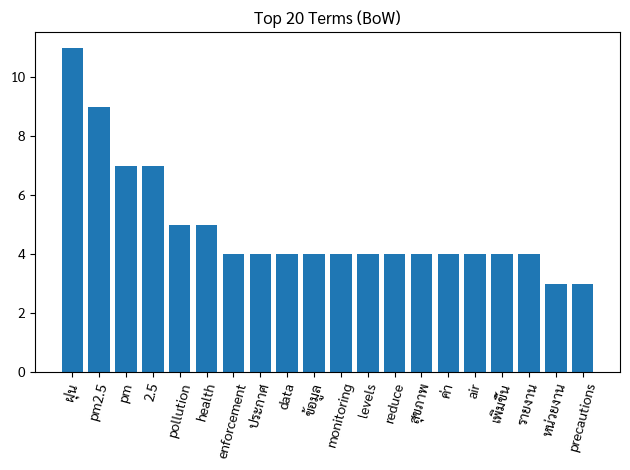

In [43]:
# Plot top terms

plt.bar(top_terms["term"], top_terms["count"])
plt.xticks(rotation=75)
plt.title("Top 20 Terms (BoW)")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## 4.5 TF-IDF

In [44]:
# สร้าง TF-IDF

tfidf = TfidfVectorizer(min_df=1, tokenizer=lambda text: text.split(), token_pattern=None)
X_tfidf = tfidf.fit_transform(df["tokens_joined"])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (18, 165)


In [45]:
# หาคำที่สำคัญที่สุดในเอกสาร 1 ชิ้น (Document-level explanation)

doc_id = 0  # เปลี่ยนดูเอกสารอื่นได้
row = X_tfidf[doc_id].toarray().ravel()
terms = np.array(tfidf.get_feature_names_out())

top_idx = row.argsort()[::-1][:15]
pd.DataFrame({
    "term": terms[top_idx],
    "tfidf": row[top_idx]
})

,term,tfidf
0,ระดับ,0.404018
1,รายงาน,0.363176
2,pm,0.331497
3,2.5,0.331497
4,พื้นที่,0.230791
5,ชี้,0.230791
6,ปกติ,0.230791
7,กรุงเทพฯ,0.230791
8,คุณภาพ,0.202009
9,อากาศ,0.202009


## 4.6 Mini NLP Task: Weak Labeling + Classification

In [46]:
# สร้าง label แบบ heuristic (policy / health / report)
# แนวคิด: ใช้ keyword กำหนด label เบื้องต้นเพื่อทำ prototype

def weak_label(text: str) -> str:
    t = text
    # กลุ่มนโยบาย
    if any(k in t for k in ["มาตรการ","นโยบาย","ประกาศ","บังคับใช้","กฎหมาย","หน่วยงาน","รัฐบาล","policy","government","regulation","regulations","enforcement","authorities"]):
        return "policy"
    # กลุ่มสุขภาพ
    if any(k in t for k in ["สุขภาพ","แพทย์","โรงพยาบาล","ผู้ป่วย","ความเสี่ยง","คำแนะนำ","doctor","doctors","health","medical","risk","precautions","experts","elderly","children"]):
        return "health"
    # กลุ่มรายงานสถานการณ์
    if any(k in t for k in ["รายงาน","ข้อมูล","ตรวจวัด","สถานการณ์","ระดับ","monitoring","data","report","levels","concentration","air quality"]):
        return "report"
    return "other"

df["label"] = df["text_clean"].apply(weak_label)
df[["title","label"]]

,title,label
0,รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น,report
1,สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง,report
2,สถานการณ์ PM2.5 ล่าสุด: ค่าฝุ่นเกินมาตรฐานบางจุด,report
3,Air quality report shows PM2.5 levels increasing,report
4,PM2.5 concentration remains above normal in la...,report
5,Monitoring data update: PM2.5 levels fluctuate,report
6,ประกาศมาตรการควบคุมการเผาในที่โล่ง,policy
7,รัฐบาลออกนโยบายลดมลพิษจากแหล่งกำเนิด,policy
8,หน่วยงานเร่งตรวจสอบและบังคับใช้กฎหมายมลพิษ,policy
9,Government announces new policy measures to re...,policy


In [47]:
# Train/test split + Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# ใช้ TF-IDF เป็น feature
X = X_tfidf
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=555, stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      health       1.00      1.00      1.00         2
      policy       1.00      1.00      1.00         2
      report       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [48]:
# แสดงคำสำคัญของแต่ละคลาส (สำหรับ binary/multiclass logistic regression)

feature_names = np.array(tfidf.get_feature_names_out())

for i, cls in enumerate(clf.classes_):
    coef = clf.coef_[i]
    top_pos = coef.argsort()[::-1][:10]
    print("\nClass:", cls)
    print(pd.DataFrame({"term": feature_names[top_pos], "weight": coef[top_pos]}))


Class: health
          term    weight
0       health  0.359842
1  precautions  0.241752
2         high  0.235953
3         risk  0.232545
4        แพทย์  0.202949
5   ความเสี่ยง  0.202949
6        risks  0.187772
7     exposure  0.187772
8         warn  0.187772
9      doctors  0.187772

Class: policy
          term    weight
0  enforcement  0.290193
1      actions  0.240577
2      ตรวจสอบ  0.239248
3     measures  0.233162
4   government  0.233162
5       กฎหมาย  0.209412
6     หน่วยงาน  0.209412
7   regulation  0.188884
8     stricter  0.187937
9      burning  0.187937

Class: report
            term    weight
0          ระดับ  0.280959
1         report  0.267142
2         ข้อมูล  0.249215
3      ต่อเนื่อง  0.208330
4           สรุป  0.208330
5  concentration  0.197826
6         normal  0.197826
7         latest  0.197826
8         levels  0.187973
9        quality  0.187973


# 5) Hands-on

## 5.1 Dataset Setup

> Dataset นี้จำลองข้อความ feedback จากผู้ใช้งาน  
> มีทั้งภาษาไทยและภาษาอังกฤษ

```python
import pandas as pd

data = [
    {"text": "ระบบใช้งานช้ามาก เข้าใช้งานไม่ได้ช่วงเย็น", "lang": "th"},
    {"text": "แอปค้างบ่อยและเกิดข้อผิดพลาดหลายครั้ง", "lang": "th"},
    {"text": "The application crashes frequently and is very slow", "lang": "en"},
    {"text": "Service response time is unacceptable", "lang": "en"},

    {"text": "ขอทราบวิธีการเปลี่ยนรหัสผ่าน", "lang": "th"},
    {"text": "ต้องการสอบถามขั้นตอนการสมัครสมาชิก", "lang": "th"},
    {"text": "Please provide instructions for account recovery", "lang": "en"},
    {"text": "I would like to know how to upgrade my plan", "lang": "en"},

    {"text": "ระบบใช้งานง่ายและสะดวกมาก", "lang": "th"},
    {"text": "เจ้าหน้าที่ให้บริการดีมาก", "lang": "th"},
    {"text": "Great user experience and friendly support", "lang": "en"},
    {"text": "The service is excellent and very helpful", "lang": "en"},
]

df = pd.DataFrame(data)
df
```

## 5.2 Text Cleaning

```python
import re

def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-zก-๙0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["text_clean"] = df["text"].apply(clean_text)
df[["text", "text_clean"]]
```

## 5.3 Tokenization (Thai & English)

```python
from pythainlp.tokenize import word_tokenize

def tokenize_auto(text: str, lang: str):
    if lang == "th":
        return word_tokenize(text, engine="newmm")
    else:
        return text.split()

df["tokens"] = df.apply(lambda r: tokenize_auto(r["text_clean"], r["lang"]), axis=1)
df[["text", "tokens"]]
```

## 5.4 Exercise

### Task 1: Design Your Own Keywords

จัดกลุ่มข้อความออกเป็น 3 ประเภท:

* `complaint` — ข้อร้องเรียน / ปัญหา
* `request` — การขอข้อมูล / ความช่วยเหลือ
* `praise` — คำชื่นชม

ให้ออกแบบ **keyword sets เอง**
(อย่างน้อยกลุ่มละ 4–6 คำ, ไทยหรืออังกฤษก็ได้)

```python
# TODO: เติม keyword ที่ออกแบบเอง

COMPLAINT_KW = {
    # ตัวอย่าง: "ช้า", "ค้าง", ...
}

REQUEST_KW = {
    # ตัวอย่าง: "ขอ", "how", ...
}

PRAISE_KW = {
    # ตัวอย่าง: "ดี", "great", ...
}
```

> 💡 คำแนะนำ:
>
> * เลือกคำที่ “ชี้ intent” ได้แรง
> * ไม่จำเป็นต้องครอบคลุมทุกกรณี
> * คำควรต่างกันระหว่างกลุ่มให้ชัด

COMPLAINT_KW = {
    "แย่", "ช้า", "เสีย", "พัง", "ผิดหวัง", "ไม่โอเค", "ห่วย", "แพง", "อันตราย", "error", "bug", "crash", "not working", "doesn't work", "poor", "dirty", "risk"
}

REQUEST_KW = {
    "ไหม", "มั้ย", "หรือ", "ยังไง", "อย่างไร", "เท่าไหร่", "เมื่อไหร่", "ทำไม", "how", "policy", "why", "what", "when", "where", "which"
}

PRAISE_KW = {
    "ดี", "ดีมาก", "เยี่ยม", "ประทับใจ", "รวดเร็ว", "ชอบ", "ยอดเยี่ยม", "สะอาด", "good", "great", "excellent", "amazing", "love", "liked", "awesome", "fast", "quick"
}

### Task 2: Weak Labeling (ออกแบบกฎเอง)

เขียนฟังก์ชัน `weak_label()` โดย

* ใช้ keyword ที่กำหนดเองก่อนหน้านี้
* กำหนด **ลำดับความสำคัญ (priority)** เอง
* ตัดสินใจว่าจะทำอย่างไรถ้าไม่เข้าเงื่อนไขใดเลย

```python
def weak_label(text: str) -> str:
    t = text.lower()
    
    # TODO: เขียนกฎการให้ label ของคุณเอง
    # ตัวอย่าง:
    # if any(k in t for k in COMPLAINT_KW):
    #     return "complaint"
    # ...
    
    return None
```

```python
df["label"] = df["text_clean"].apply(weak_label)
df[["text", "label"]]
```

In [60]:
COMPLAINT_KW = {
    "แย่", "ช้า", "เสีย", "พัง", "ผิดหวัง", "ไม่โอเค", "ห่วย", "แพง", "อันตราย", "error", "bug", "crash", "not working", "doesn't work", "poor", "dirty", "risk"
}

REQUEST_KW = {
    "ไหม", "มั้ย", "หรือ", "ยังไง", "อย่างไร", "เท่าไหร่", "เมื่อไหร่", "ทำไม", "how", "policy", "why", "what", "when", "where", "which"
}

PRAISE_KW = {
    "ดี", "ดีมาก", "เยี่ยม", "ประทับใจ", "รวดเร็ว", "ชอบ", "ยอดเยี่ยม", "สะอาด", "good", "great", "excellent", "amazing", "love", "liked", "awesome", "fast", "quick"
}

def weak_label(text: str) -> str:
    t = text.lower()

    if any(k in t for k in COMPLAINT_KW):
        return "Complaint"

    elif any(k in t for k in REQUEST_KW):
        return "Request"

    elif any(k in t for k in PRAISE_KW):
        return "Praise"

    else:
        return "Other"

df["label"] = df["text_clean"].apply(weak_label)
df[["title","label"]]

,title,label
0,รายงานระดับ PM2.5 วันนี้ในกรุงเทพฯ สูงขึ้น,Other
1,สรุปข้อมูลคุณภาพอากาศ: ค่าฝุ่นยังสูงต่อเนื่อง,Complaint
2,สถานการณ์ PM2.5 ล่าสุด: ค่าฝุ่นเกินมาตรฐานบางจุด,Other
3,Air quality report shows PM2.5 levels increasing,Request
4,PM2.5 concentration remains above normal in la...,Request
5,Monitoring data update: PM2.5 levels fluctuate,Request
6,ประกาศมาตรการควบคุมการเผาในที่โล่ง,Other
7,รัฐบาลออกนโยบายลดมลพิษจากแหล่งกำเนิด,Other
8,หน่วยงานเร่งตรวจสอบและบังคับใช้กฎหมายมลพิษ,Other
9,Government announces new policy measures to re...,Request


### Task 3: ตรวจสอบการกระจายของ label

```python
df["label"].value_counts()
```

> คำถามให้คิด:
>
> * มี label ไหนมากหรือน้อยเกินไปหรือไม่
> * มีข้อความใดที่คุณรู้สึกว่า “ติด label ผิด” เพราะกฎที่ตั้งขึ้นหรือไม่

1. พบว่า Other มากเกินไป เพราะกฎไม่ครอบคลุมคำทั้งหมด label อื่นอาจน้อยถ้า Keyword แคบเกินไป

2. ไม่มี

### Task 4: Feature Extraction: TF-IDF

```python
from sklearn.feature_extraction.text import TfidfVectorizer

df["tokens_joined"] = df["tokens"].apply(lambda xs: " ".join(xs))

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df["tokens_joined"])
y = df["label"]

X.shape
```

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

df["tokens_joined"] = df["tokens"].apply(lambda xs: " ".join(xs))

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df["tokens_joined"])
y = df["label"]

X.shape

(18, 168)

### Task 5: Classification

```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=??,
    random_state=??,
    stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
```

> ⚠️ หมายเหตุ
>
> * dataset มีขนาดเล็ก → metric อาจไม่นิ่ง
> * จุดประสงค์คือ **เข้าใจ pipeline ไม่ใช่แข่งขัน accuracy**

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Complaint       0.00      0.00      0.00         1
       Other       0.50      1.00      0.67         2
     Request       0.00      0.00      0.00         1

    accuracy                           0.50         4
   macro avg       0.17      0.33      0.22         4
weighted avg       0.25      0.50      0.33         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Task 6: Interpretation

ดูคำที่มีผลต่อการตัดสินใจของโมเดล

```python
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())

for i, cls in enumerate(clf.classes_):
    coef = clf.coef_[i]
    top_idx = coef.argsort()[::-1][:5]
    print(f"\nClass: {cls}")
    for term, w in zip(feature_names[top_idx], coef[top_idx]):
        print(f"  {term:15s} {w:.3f}")
```

ตอบคำถาม:

* คำใดทำให้โมเดลมองว่าเป็น `complaint`
* คำใดสะท้อน `praise`
* มีคำใดที่คุณ “ไม่คาดคิด” ไหม

In [63]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())

for i, cls in enumerate(clf.classes_):
    coef = clf.coef_[i]
    top_idx = coef.argsort()[::-1][:5]
    print(f"\nClass: {cls}")
    for term, w in zip(feature_names[top_idx], coef[top_idx]):
        print(f"  {term:15s} {w:.3f}")


Class: Complaint
  สร              0.278
  อเน             0.278
  health          0.269
  warn            0.233
  risks           0.233

Class: Other
  รายงาน          0.216
  เพ              0.205
  ลด              0.156
  ประกาศ          0.153
  enforcement     0.145

Class: Request
  levels          0.461
  pm2             0.393
  monitoring      0.369
  data            0.369
  quality         0.308


1. คำใดทำให้โมเดลมองว่าเป็น complaint

    health / warn / risks
    โมเดลมองว่า ขประโยคหรือข้อความที่พูดถึงสุขภาพ มีแนวโน้มเป็น complaint

2. คำใดสะท้อน praise

    ไม่มี

3. มีคำใดที่คุณ “ไม่คาดคิด” ไหม

    health เพราะ ไม่ใช่คำดีบ่งบอกถึงเหตุการณ์ แต่เป็นคำนามปกติ การจัดไปอยู่ใน complaint บางครั้งอาจทำให้ตีความไม่ถูกต้อง

# 6) Reflection

ตอบคำถามต่อไปนี้เป็นข้อความสั้น ๆ

1. Tokenization เป็น “จุดตัดสินใจ” สำคัญของภาษาไทยอย่างไร
2. BoW/TF-IDF สูญเสียข้อมูลอะไร และผลกระทบคืออะไร
3. ในบริบทข่าว PM2.5 คุณจะใช้ NLP เพื่อสร้าง feature แบบไหนได้บ้าง (ยก 2 ตัวอย่าง)

1. Tokenization สำคัญ เพราะ ภาษาไทยไม่มีเว้นวรรคระหว่างคำ ถ้าตัดคำผิด ความหมายจะเปลี่ยน ทำให้โมเดลเรียนรู้ผิดได้

2. BoW / TF-IDF สูญเสียลำดับคำและบริบท เช่น ไม่ดี อาจถูกมองว่า ดี ส่งผลให้โมเดลตีความผิด

3. Feature สำหรับข่าว PM2.5

    1. นับ keyword เช่น เกินมาตรฐาน มาตรการ มลพิษ

    2. ดึงชื่อสถานที่หรือค่าตัวเลข PM2.5 เพื่อดูพื้นที่และระดับความรุนแรง

# 7) Deliverables for This Week

* [ ] Hands-on ครบทุก task
* [ ] Reflection questions